In [858]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import clone
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [834]:
def print_stats(r2_1, mse_1, thresholds=[0.5, 0.8]):
    r2_1, mse_1 = np.array(r2_1), np.array(mse_1)

    def summary_stats(metric):
        return (np.nanmean(metric), np.nanmedian(metric), np.nanmax(metric), np.nanmin(metric))

    r2_1_stats = summary_stats(r2_1)
    mse_1_stats = summary_stats(mse_1)

    
    print(f"Model 1 R²: Mean={r2_1_stats[0]:.4f}, Median={r2_1_stats[1]:.4f}, Max={r2_1_stats[2]:.4f}, Min={r2_1_stats[3]:.4f}")

    print(f"Model 1 MSE: Mean={mse_1_stats[0]:.2e}, Median={mse_1_stats[1]:.2e}, Max={mse_1_stats[2]:.2e}, Min={mse_1_stats[3]:.2e}")

    for t in thresholds:
        count1 = np.sum(r2_1 > t)
        print(f"Signatures with R² > {t}: {count1}")
    print()

In [903]:
class PredictExposureWith0Sensitivity:
    def __init__(self, model):
        self.model = model

    def fit(self, X_train, y_bin_train, y_exp_train):
        regressors = []
        for i in range(y_bin_train.shape[1]):       # for each of the 29 binarized label
            idx_train = y_bin_train[:, i] == 1  # if the signature for that sample i 0 do not use it for training the regressor on that signature
            if not np.any(idx_train):
                regressors.append(None)
                continue
            y_train_i = y_exp_train[idx_train, i]

            model_i = clone(self.model)
            model_i.fit(X_train[idx_train], y_train_i)
            regressors.append(model_i)
        return regressors

    def evaluate(self, regressors, X_test, y_bin_test, y_exp_test):
        r2_scores = []
        mse_scores = []
        predictions = []

        for i, model_i in enumerate(regressors):
            y_pred_i = np.zeros(y_bin_test.shape[0])
            idx_test = y_bin_test[:, i] == 1

            if model_i is not None and np.any(idx_test):
                y_pred_i[idx_test] = model_i.predict(X_test[idx_test])

                y_test_i = y_exp_test[idx_test, i]
                r2_scores.append(r2_score(y_test_i, y_pred_i[idx_test]))
                mse_scores.append(mean_squared_error(y_test_i, y_pred_i[idx_test]))
            else:
                r2_scores.append(np.nan)
                mse_scores.append(np.nan)

            predictions.append(y_pred_i)

        return r2_scores, mse_scores, predictions


### Prediction with the LightGBMXT model

In [836]:
# predictor = MultilabelPredictor.load('../models/saved/Predictor-0.03')
# new_base_path = '../models/saved/Predictor-0.03'
# pred_mutation_count = pd.read_csv('../simulations/data2/run_1/trinucleotides_counts_sampling_0.03.csv').iloc[:,1:]
# # aggiorna i path per ogni label
# for label in predictor.labels:
#     predictor.predictors[label] = os.path.join(new_base_path, f'Predictor_{label}')
    
# prediction = predictor.predict(pred_mutation_count)

## Prediction with the GT

### Split train and test Data

train feature data:
- 96 values indicating the mutation count for each type of mutation
- 29 binary labels

train target data:
- 29 real numbers indicating the exposure value 

In [904]:
seed = np.random.randint(1,100000)
np.random.seed(seed=seed)
train_size = 0.85
# Loading the data
signature_prob_distribution = pd.read_csv('../simulations/ground_truth/signatures.csv').iloc[:,1:].values
mutation_count = pd.read_csv('../simulations/data/run_1/trinucleotides_counts_sampling_0.03.csv').iloc[:,1:].values  # N x 96
mutation_count_bin = pd.read_csv('../simulations/ground_truth/bin_exposures.csv').iloc[:,1:].astype(int).values  # N x 29

signature_exposure = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:,1:].values  # N x 29
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            mutation_count, mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )

### Simple Linear Regressor

In [905]:
pes_0 = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes_0.fit(X_train, y_bin_train, y_exp_train)
r2_0,mse_0,pred_0 = pes_0.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [907]:
print_stats(r2_0,mse_0)

Model 1 R²: Mean=-3.6189, Median=0.8509, Max=0.9994, Min=-121.4572
Model 1 MSE: Mean=2.88e+07, Median=4.03e+06, Max=3.31e+08, Min=1.44e+05
Signatures with R² > 0.5: 24
Signatures with R² > 0.8: 16



In [ ]:
r2s = []

In [908]:
for i in range(100):
    seed=np.random.randint(1,100000)
    X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            mutation_count, mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )
    model = PredictExposureWith0Sensitivity(LinearRegression())
    regressors = model.fit(X_train, y_bin_train, y_exp_train)
    r2,mse,pred = model.evaluate(regressors, X_test, y_bin_test, y_exp_test)
    r2s.append(r2)

<Axes: >

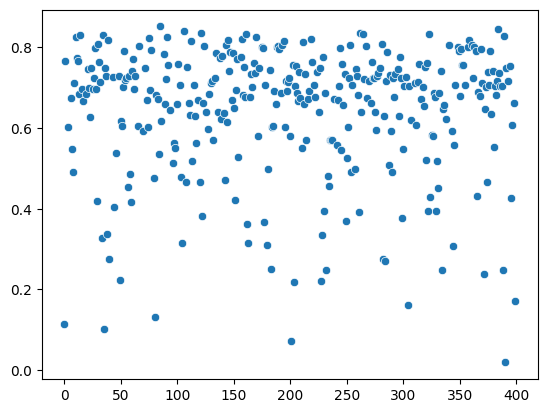

In [911]:
r2s_array = np.array(r2s)
means = np.mean(r2s_array, axis=1)
x_vals = np.arange(len(means))

# Filtra valori > 0
mask = means >= 0
sns.scatterplot(x=x_vals[mask], y=means[mask], legend=False)

In [898]:
print(f'n. valori tra 0 e 0.5: {np.sum((means >= 0) & (means <= 0.5))}\nn-valori tra 0.5 e 1 {np.sum((means >= 0.5))}')


n. valori tra 0 e 0.5: 43
n-valori tra 0.5 e 1 212


### Simple linear Regressor with the mutation count accounted for the signature probability distribution

In [842]:
signature_exposure = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:,1:].values  # N x 29
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            mutation_count @ signature_prob_distribution.T, mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )

In [843]:
pes_2 = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes_2.fit(X_train, y_bin_train, y_exp_train)
r2_2,mse_2,pred_2 = pes_2.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [844]:
print_stats(r2_2,mse_2)

Model 1 R²: Mean=0.8259, Median=0.8985, Max=0.9993, Min=-0.2628
Model 1 MSE: Mean=3.65e+06, Median=1.12e+06, Max=3.17e+07, Min=7.98e+04
Signatures with R² > 0.5: 27
Signatures with R² > 0.8: 20



### Simple linear Regressor with the mutation count accounted for the signature probability distribution and tissue sample

In [845]:
from sklearn.preprocessing import LabelEncoder
tissues = pd.read_csv('../simulations/ground_truth/tumor_site.csv').iloc[:,1:-1].values
encoder = LabelEncoder()
tissues_encoded = pd.DataFrame(encoder.fit_transform(tissues))

/home/massimo/Documents/stage/signature_inference/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [846]:
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            np.hstack([mutation_count @ signature_prob_distribution.T,tissues_encoded]), mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )

In [847]:
pes_3 = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes_3.fit(X_train, y_bin_train, y_exp_train)
r2_3,mse_3,pred_3 = pes_3.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [848]:
print_stats(r2_3, mse_3)

Model 1 R²: Mean=0.8262, Median=0.9003, Max=0.9993, Min=-0.2590
Model 1 MSE: Mean=3.65e+06, Median=1.13e+06, Max=3.17e+07, Min=7.98e+04
Signatures with R² > 0.5: 27
Signatures with R² > 0.8: 20



In [849]:
seed
# 8070

66405